# Handmarks Extraction Pipeline

This notebook explains the Phase 2 feature-extraction pipeline used to build `handmarks.csv` from the collected hand images.

## 1. Goal

The Phase 2 model does not classify directly from image pixels. Instead, it follows this flow:

1. Read labeled images from `src/Data/collected/<class>`
2. Detect a hand with MediaPipe through `HandDetector`
3. Extract a compact set of geometric features from selected landmarks
4. Save one feature row per image into `handmarks.csv`
5. Train an SVM on that CSV

The goal is to turn each image into a small numeric feature vector that describes hand geometry.

In [ ]:
import os
import sys
import csv
import cv2
import logging
from pathlib import Path
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    src_dir = candidate / "src"
    if (src_dir / "utils").exists():
        sys.path.append(str(src_dir))
        break

from utils.feature_extraction import distance, vector, mean_position, angle_between

ModuleNotFoundError: No module named 'cv2'

## 2. Input Data

The pipeline reads labeled image folders from `src/Data/collected`. Each folder name is used as the class label, and the extracted features are written to `src/Data/handmarks.csv`.

In [ ]:
cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    src_dir = candidate / "src"
    if (src_dir / "utils").exists():
        BASE_DIR = str(src_dir)
        break
else:
    raise RuntimeError("Could not find project src directory")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, "Data", "collected")
OUTPUT_CSV = os.path.join(BASE_DIR, "Data", "handmarks.csv")

print(f"Input data directory: {DATA_DIR}")
print(f"Output feature CSV:   {OUTPUT_CSV}")

Input data directory: /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/Data/collected
Output feature CSV:   /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/Data/handmarks.csv


## 3. Hand Detection

Each image is passed through `HandDetector`, which returns the hand landmarks used by the feature extractor. The rest of the pipeline depends on those detected points.

In [36]:
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

detector = HandDetector(num_hands=1)
detector

W0000 00:00:1776874764.671793   16537 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776874764.685353   16537 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4. Selected Landmarks

The pipeline keeps a subset of the detected landmarks:

- Wrist: `0`
- Thumb base/tip: `1`, `3`
- Index base/tip: `4`, `6`
- Middle base/tip: `7`, `9`
- Ring base/tip: `10`, `12`
- Pinky base/tip: `13`, `15`

These points are enough to describe finger position, curl, and hand orientation without using every landmark.

In [37]:
selected_landmarks = [0, 1, 3, 4, 6, 7, 9, 10, 12, 13, 15]

## 5. Normalization

The coordinates are normalized in two steps:

1. Use the wrist as the origin
2. Divide coordinates by hand scale

Hand scale is computed from the distance between landmarks `1` and `13`. This makes the features less sensitive to image position and hand size.

In [38]:
def normalization_demo_snippet(landmarks):
    wrist_x = landmarks[0][0]
    wrist_y = landmarks[0][1]
    raw_1 = landmarks[1]
    raw_13 = landmarks[13]
    hand_scale_px = ((raw_1[0] - raw_13[0]) ** 2 + (raw_1[1] - raw_13[1]) ** 2) ** 0.5

    normalized_points = {}
    for idx in [0, 1, 3, 4, 6, 7, 9, 10, 12, 13, 15]:
        x = (landmarks[idx][0] - wrist_x) / hand_scale_px
        y = (landmarks[idx][1] - wrist_y) / hand_scale_px
        normalized_points[idx] = (x, y)

    return normalized_points

## 6. Invalid Detection Filtering

Before extracting features, the pipeline checks whether the detected hand scale is reasonable for the image. If it is too small or too large, the sample is rejected.

In [39]:
def hand_scale_validation_snippet(hand_scale_px, image_shape):
    h, w = image_shape[:2]
    norm_scale = hand_scale_px / min(h, w)
    if norm_scale < 0.05 or norm_scale > 0.8:
        return None
    return norm_scale

## 7. Feature Groups

The feature extractor builds the final vector in groups:

- distance features
- curl features
- height features
- orientation features
- spread features

Instead of storing raw landmark coordinates, the pipeline computes geometric features that describe the hand shape more directly.

In [40]:
feature_groups = {
    "distance": [
        "thumb_index_dist",
        "index_middle_dist",
        "middle_ring_dist",
        "ring_pinky_dist",
        "thumb_ring_dist",
        "thumb_pinky_dist",
    ],
    "curl": [
        "thumb_curl",
        "index_curl",
        "middle_curl",
        "ring_curl",
        "pinky_curl",
    ],
    "height": ["thumb_y", "index_y", "middle_y", "ring_y", "pinky_y"],
    "orientation": ["hand_rotation", "thumb_angle", "palm_tilt"],
    "spread": ["spread_angle_1", "spread_angle_2", "y_variance"],
}

feature_groups

{'distance': ['thumb_index_dist',
  'index_middle_dist',
  'middle_ring_dist',
  'ring_pinky_dist',
  'thumb_ring_dist',
  'thumb_pinky_dist'],
 'curl': ['thumb_curl',
  'index_curl',
  'middle_curl',
  'ring_curl',
  'pinky_curl'],
 'height': ['thumb_y', 'index_y', 'middle_y', 'ring_y', 'pinky_y'],
 'orientation': ['hand_rotation', 'thumb_angle', 'palm_tilt'],
 'spread': ['spread_angle_1', 'spread_angle_2', 'y_variance']}

### 7.1 Distance Features

Distances between fingertips describe how open, closed, or spread the hand is.

In [41]:
def distance_features_snippet(normalized_points, distance):
    thumb_tip = normalized_points[3]
    index_tip = normalized_points[6]
    middle_tip = normalized_points[9]
    ring_tip = normalized_points[12]
    pinky_tip = normalized_points[15]

    return {
        "thumb_index_dist": distance(thumb_tip, index_tip),
        "index_middle_dist": distance(index_tip, middle_tip),
        "middle_ring_dist": distance(middle_tip, ring_tip),
        "ring_pinky_dist": distance(ring_tip, pinky_tip),
        "thumb_ring_dist": distance(thumb_tip, ring_tip),
        "thumb_pinky_dist": distance(thumb_tip, pinky_tip),
    }

### 7.2 Curl Features

Curl is measured with tip-to-base distances, which gives a compact way to represent whether each finger is bent or extended.

In [42]:
def curl_features_snippet(normalized_points, distance):
    return {
        "thumb_curl": distance(normalized_points[3], normalized_points[1]),
        "index_curl": distance(normalized_points[6], normalized_points[4]),
        "middle_curl": distance(normalized_points[9], normalized_points[7]),
        "ring_curl": distance(normalized_points[12], normalized_points[10]),
        "pinky_curl": distance(normalized_points[15], normalized_points[13]),
    }

### 7.3 Height, Orientation, and Spread Features

The remaining features describe fingertip height, hand orientation, thumb position, and finger spread.

In [43]:
final_feature_order = [
    "label",
    "thumb_index_dist", "thumb_index_8_dist", "index_middle_dist", "middle_ring_dist",
    "ring_pinky_dist", "thumb_ring_dist", "thumb_pinky_dist",
    "thumb_curl", "index_curl", "index_curl_8", "middle_curl", "ring_curl", "pinky_curl",
    "thumb_y", "index_y", "index_8_y", "index_5_y", "middle_y", "ring_y", "pinky_y",
    "hand_rotation", "thumb_angle", "palm_tilt",
    "spread_angle_1", "spread_angle_2", "y_variance",
]

final_feature_order

['label',
 'thumb_index_dist',
 'index_middle_dist',
 'middle_ring_dist',
 'ring_pinky_dist',
 'thumb_ring_dist',
 'thumb_pinky_dist',
 'thumb_curl',
 'index_curl',
 'middle_curl',
 'ring_curl',
 'pinky_curl',
 'thumb_y',
 'index_y',
 'middle_y',
 'ring_y',
 'pinky_y',
 'hand_rotation',
 'thumb_angle',
 'palm_tilt',
 'spread_angle_1',
 'spread_angle_2',
 'y_variance']

### 7.4 Utility Call Chain

At this point the complete call chain is:

1. `process_image()` gets landmarks from `HandDetector`
2. `process_image()` calls `extract_features_from_landmarks(...)`
3. `extract_features_from_landmarks(...)` calls the geometry helpers from `utils.feature_extraction`
4. The returned dictionary is written as one CSV row

These utility functions are the ones that actually compute the feature values.

## 8. `process_image()`

`process_image()` is the bridge between the raw image files and the feature extractor.

It does the following:

1. read an image from disk
2. reject unreadable files
3. detect the hand via `HandDetector.findHands(...)`
4. reject images where no hand is found
5. call `extract_features_from_landmarks(...)` from `utils.feature_extraction`
6. return the feature dictionary for later CSV writing
7. log exceptions without stopping the full dataset build

In [44]:
def process_image(image_path, label):
    try:
        image = cv2.imread(image_path)
        if image is None:
            return None

        hands, img_out, bbox = detector.findHands(image, draw=False)
        if not hands:
            return None

        return extract_features_from_landmarks(hands[0], image.shape, label)
    except Exception as exc:
        logger.error(f"Error processing {image_path}: {exc}")
        return None

### 8.1 Utility Calls Inside `process_image()`

This function does not compute features itself. It delegates to shared utilities:

- `HandDetector` from `utils.HandTrackingModule`
- `extract_features_from_landmarks()` from `utils.feature_extraction`

So `process_image()` handles the flow for one image, and the utils module handles the actual geometry calculations.

## 9. CSV Writing

The extraction loop goes through each class folder and each image file. A row is written only when `process_image()` returns valid features.

In [45]:
fieldnames = [
    "label", "thumb_index_dist", "thumb_index_8_dist", "index_middle_dist", "middle_ring_dist",
    "ring_pinky_dist", "thumb_ring_dist", "thumb_pinky_dist", "thumb_curl",
    "index_curl", "index_curl_8", "middle_curl", "ring_curl", "pinky_curl", "thumb_y",
    "index_y", "index_8_y", "index_5_y", "middle_y", "ring_y", "pinky_y", "hand_rotation",
    "thumb_angle", "palm_tilt", "spread_angle_1", "spread_angle_2", "y_variance",
]

fieldnames == final_feature_order

True

In [46]:
def build_handmarks_csv(data_dir=DATA_DIR, output_csv=OUTPUT_CSV):
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Data directory not found: {data_dir}")

    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    total_extracted = 0
    class_stats = {}

    with open(output_csv, mode="w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

        for class_dir in sorted(os.listdir(data_dir)):
            class_path = os.path.join(data_dir, class_dir)
            if not os.path.isdir(class_path):
                continue

            logger.info(f"Processing class: {class_dir}...")
            success_count = 0
            total_count = 0

            for img_name in sorted(os.listdir(class_path)):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    total_count += 1
                    img_path = os.path.join(class_path, img_name)
                    features = process_image(img_path, class_dir)
                    if features:
                        writer.writerow(features)
                        success_count += 1
                        total_extracted += 1

            class_stats[class_dir] = {"success": success_count, "total": total_count}
            logger.info(f"Class {class_dir} complete: {success_count}/{total_count} extracted.")

    return {
        "output_csv": output_csv,
        "total_extracted": total_extracted,
        "class_stats": class_stats,
    }

### 9.1 `build_handmarks_csv()`

After `process_image()` handles one image, `build_handmarks_csv()` handles the dataset-level loop:

- loop through class folders
- loop through image files
- call `process_image()` per image
- write valid results to CSV in fixed column order
- count success totals per class

This produces the full CSV used later by the SVM training step.

## 10. Extraction Statistics

The script records how many images were processed successfully for each class. This gives a quick check of extraction quality before training.

In [ ]:
results = build_handmarks_csv()

INFO: Processing class: A...
INFO: Class A complete: 2181/3000 extracted.
INFO: Processing class: B...
INFO: Class B complete: 2201/3000 extracted.
INFO: Processing class: C...
INFO: Class C complete: 1959/3000 extracted.


## 11. SVM Training Input

After the CSV is created, the next step is to train the Phase 2 classifier. The training code reads `handmarks.csv`, splits the features and labels, and prepares the data for the SVM.

In [ ]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.preprocessing import StandardScaler

In [ ]:
DATA_PATH = os.path.join(BASE_DIR, "Data", "handmarks.csv")
MODEL_DIR = os.path.join(BASE_DIR, "models")
MODEL_PATH = os.path.join(MODEL_DIR, "asl_svm_model7.pkl")
SCALER_PATH = os.path.join(MODEL_DIR, "asl_scaler7.pkl")

print(f"Dataset path: {DATA_PATH}")
print(f"Model path:   {MODEL_PATH}")
print(f"Scaler path:  {SCALER_PATH}")

Dataset path: /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/Data/handmarks.csv
Model path:   /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/models/asl_svm_model.pkl
Scaler path:  /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/models/asl_scaler.pkl


## 12. Load the CSV

The training step reads the CSV produced by the extraction pipeline and separates the `label` column from the numeric features. Also checks the amount of samples per class in order to check the wether the dataset is balanced or not.
 

In [50]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df.head()

,label,thumb_index_dist,index_middle_dist,middle_ring_dist,ring_pinky_dist,thumb_ring_dist,thumb_pinky_dist,thumb_curl,index_curl,middle_curl,...,index_y,middle_y,ring_y,pinky_y,hand_rotation,thumb_angle,palm_tilt,spread_angle_1,spread_angle_2,y_variance
0,A,0.351823,0.506113,0.627995,0.312439,0.889217,0.953630,1.012996,0.230444,0.383677,...,-1.442507,-1.126341,-0.513770,-0.691613,-1.084764,0.289504,-2.230106,-2.773327,1.936479,0.132639
1,A,0.319776,0.479848,0.660438,0.277252,0.833874,0.912613,0.993810,0.229213,0.397896,...,-1.370786,-1.126674,-0.488225,-0.619671,-1.084764,0.281232,-2.169215,-2.854386,1.913587,0.130289
2,A,0.408805,0.485815,0.443999,0.315580,0.923396,1.075588,1.090702,0.408805,0.268897,...,-1.514820,-1.123056,-0.679057,-0.809645,-1.306308,0.335639,-2.282255,-2.950669,1.949248,0.103854
3,A,0.301598,0.479718,0.567913,0.277827,0.799031,0.820120,1.031220,0.239560,0.338788,...,-1.507609,-1.185760,-0.643698,-0.813092,-1.142018,0.340382,-2.248183,-2.891291,1.783112,0.112105
4,A,0.314496,0.488559,0.540411,0.287547,0.842698,0.844363,1.096868,0.274785,0.304926,...,-1.572085,-1.201144,-0.671227,-0.865530,-1.135712,0.420197,-2.193099,-2.875341,1.705863,0.117473


In [51]:
X = df.drop("label", axis=1)
y = df["label"]
classes = sorted(y.unique())

print(f"Dataset shape: {df.shape}")
print("\nClass Distribution:")
dist = y.value_counts(normalize=True) * 100
for cls, pct in dist.items():
    print(f"  {cls}: {pct:.2f}% ({y.value_counts()[cls]} samples)")

Dataset shape: (6341, 23)

Class Distribution:
  B: 34.71% (2201 samples)
  A: 34.40% (2181 samples)
  C: 30.89% (1959 samples)


## 13. Train/Test Split and Scaling

The data is split on 80% training data and 20% test data. As SVMs are distance-based classifiers, scaling ensures that features with larger numerical ranges don't dominate the distance calculations.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")

Training rows: 5072
Test rows:     1269


## 14. Hyperparameter Search

To ensure the model generalizes well and to find the optimal hyperparameters (`C` and `gamma`), we use `GridSearchCV`. This tool automatically performs **k-fold cross-validation** (default `cv=5`) during the parameter search, reducing the risk of being "lucky" or "unlucky" with a single data split.

In [53]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
}

grid_search = GridSearchCV(
    SVC(kernel="rbf", class_weight="balanced", random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation weighted F1-score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 100, 'gamma': 0.001}
Best cross-validation weighted F1-score: 0.9996


## 15. Evaluation

After the best model is selected, it is evaluated on the held-out test set with accuracy, balanced accuracy, macro F1, and Matthews correlation coefficient.

In [ ]:
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("=" * 30)
print(f"Test Accuracy:          {accuracy:.4%}")
print(f"Balanced Accuracy:      {balanced_acc:.4%}")
print(f"Macro F1-Score:         {macro_f1:.4f}")

print("=" * 30)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred))

Test Accuracy:          99.8424%
Balanced Accuracy:      99.8385%
Macro F1-Score:         0.9984
Matthews Corr Coeff:    0.9976

Classification Report (Test Set):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       436
           B       1.00      1.00      1.00       441
           C       1.00      1.00      1.00       392

    accuracy                           1.00      1269
   macro avg       1.00      1.00      1.00      1269
weighted avg       1.00      1.00      1.00      1269



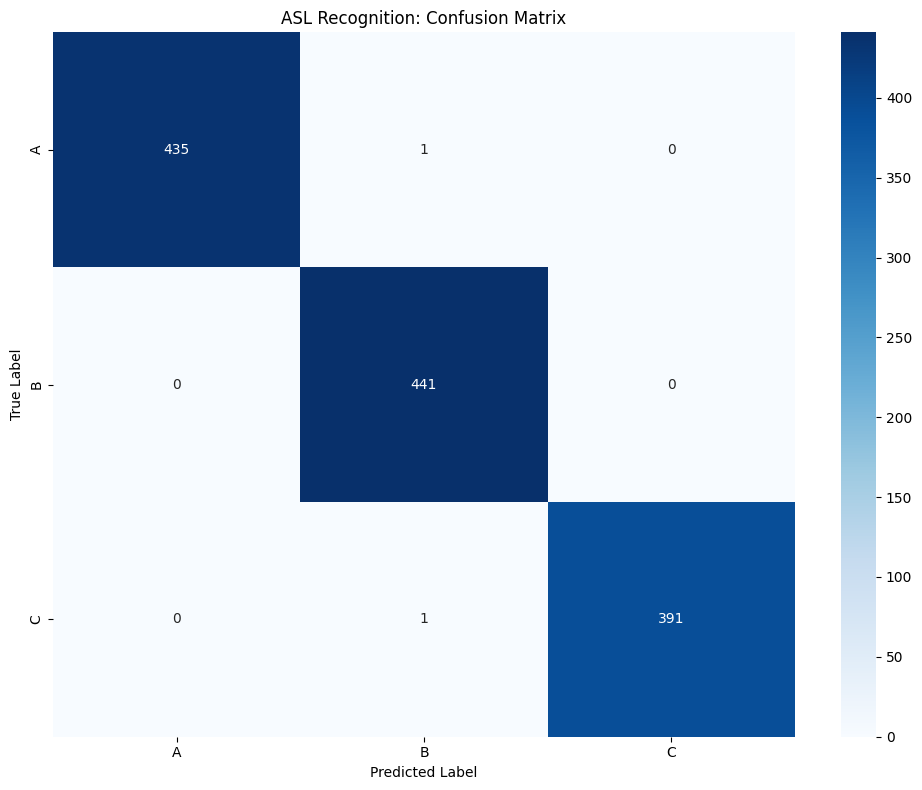

In [55]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("ASL Recognition: Confusion Matrix")
plt.tight_layout()
plt.show()

## 16. Save the Trained Artifacts

The final step saves the confusion matrix image, the trained SVM model, and the fitted scaler into `src/models`.

In [56]:
os.makedirs(MODEL_DIR, exist_ok=True)

cm_plot_path = os.path.join(MODEL_DIR, "confusion_matrix.png")
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("ASL Recognition: Confusion Matrix")
plt.tight_layout()
plt.savefig(cm_plot_path)
plt.close()

joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f"Confusion matrix saved to {cm_plot_path}")
print(f"Saved best model to {MODEL_PATH}")
print(f"Saved scaler to {SCALER_PATH}")

Confusion matrix saved to /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/models/confusion_matrix.png
Saved best model to /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/models/asl_svm_model.pkl
Saved scaler to /home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/src/models/asl_scaler.pkl


## 18. End-to-End Summary

The final Phase 2 extraction logic is:

1. Read labeled images from class folders
2. Detect a hand in each image
3. Keep only a chosen subset of landmarks
4. Normalize by wrist position and hand scale
5. Compute interpretable geometric features
6. Reject invalid detections
7. Write valid samples to `handmarks.csv`
8. Use that CSV as input for SVM training

This is the full extraction pipeline used before Phase 2 SVM training.

## 19. Run the Model

After training, the saved model and scaler can be used with the real-time classifier in `src/SVMclassification.py`.

In [ ]:
# python src/SVMclassification.py --model asl_svm_model.pkl --scaler asl_scaler.pkl